In [1]:
from pinballrt.dust import load

d = load("../pinballrt/tests/data/diana_wice.dst")

In [17]:
from schwimmbad import MultiPool
from numpy.random import SeedSequence, seed, randint, set_state
import pandas as pd
from tqdm.auto import tqdm

pool = MultiPool(initializer=tqdm.set_lock, initargs=(tqdm.get_lock(),))

def run_dust_simulation(x):
    s, position = x
    seed(s.generate_state(1)[0])
    #df = d.run_dust_simulation(nphotons=1000000, tau_range=(30., 1e4), nu_range=(d.nu.min(), d.nu.max()), position=position, time_limit=301700)
    df = d.run_dust_simulation(nphotons=1000000, tau_range=(30., 1e4), nu_range=(d.nu.min(), d.nu.max()), position=position, time_limit=600)
    return df

result = pool.map(run_dust_simulation, list(zip(SeedSequence(12345).spawn(pool.size), range(pool.size))))

new_df = pd.concat(result, axis=0)

df = pd.concat((df, new_df), axis=0)

/Users/psheehan/pinball-rt/pinballrt/dust.py:853: RuntimeWarning: divide by zero encountered in log10
  "log10_tau":np.log10(photon_list.tau.numpy().copy()),
/Users/psheehan/pinball-rt/pinballrt/dust.py:853: RuntimeWarning: divide by zero encountered in log10
  "log10_tau":np.log10(photon_list.tau.numpy().copy()),
/Users/psheehan/pinball-rt/pinballrt/dust.py:853: RuntimeWarning: divide by zero encountered in log10
  "log10_tau":np.log10(photon_list.tau.numpy().copy()),
/Users/psheehan/pinball-rt/pinballrt/dust.py:853: RuntimeWarning: divide by zero encountered in log10
  "log10_tau":np.log10(photon_list.tau.numpy().copy()),
/Users/psheehan/pinball-rt/pinballrt/dust.py:853: RuntimeWarning: divide by zero encountered in log10
  "log10_tau":np.log10(photon_list.tau.numpy().copy()),
/Users/psheehan/pinball-rt/pinballrt/dust.py:853: RuntimeWarning: invalid value encountered in log10
  "log10_tau":np.log10(photon_list.tau.numpy().copy()),
/Users/psheehan/pinball-rt/pinballrt/dust.py:853: Run

In [22]:
df.to_csv("sim_results_pre-filter.csv")

In [2]:
d.learn(model="ml_step_filter")
d.fit(epochs=10, batch_size=1000000)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/psheehan/.pyenv/versions/anaconda3-2023.03/envs/warp/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/psheehan/.pyenv/versions/anaconda3-2023.03/envs/warp/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:658: Checkpoint directory /Users/psheehan/pinball-rt/examples/ml_step_filter_lightning_logs exists and is not empty.

  | Name  | Type                 | Params | Mode 
-----------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/psheehan/.pyenv/versions/anaconda3-2023.03/envs/warp/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/psheehan/.pyenv/versions/anaconda3-2023.03/envs/warp/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [26]:
d.dataset.tensors[1].shape

torch.Size([100000, 5])

In [3]:
d.learn(model='ml_step', hidden_units=((128, 128),)*6, overwrite=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
d.fit(epochs=500, batch_size=800000)

: 

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │     3.517261028289795     │
└───────────────────────────┴───────────────────────────┘

Predicting: |          | 0/? [00:00<?, ?it/s]

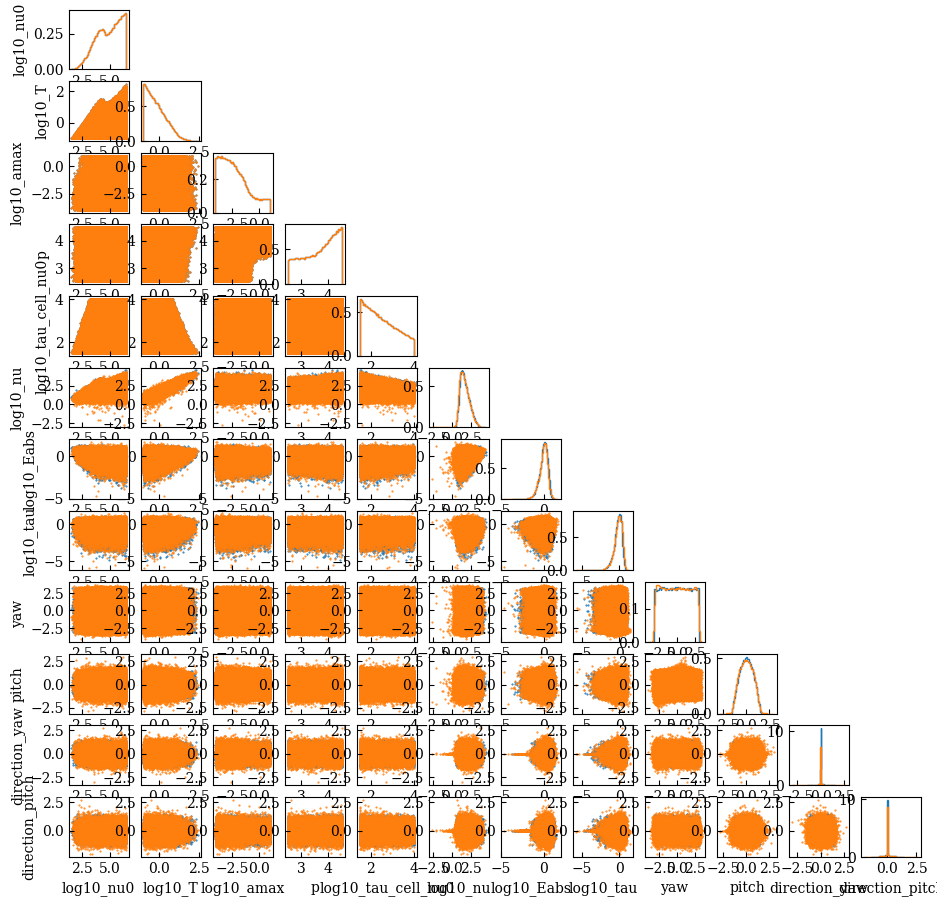

In [4]:
d.test_model(plot=True)

  0%|          | 0/100000 [00:00<?, ?it/s]

/Users/psheehan/pinball-rt/pinballrt/dust.py:853: RuntimeWarning: divide by zero encountered in log10
  "log10_tau":np.log10(photon_list.tau.numpy().copy()),
/Users/psheehan/pinball-rt/pinballrt/dust.py:898: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.06663529 -1.38698256  0.21201278 ...  0.1501278   0.2260382
 -0.37452736]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[:, "log10_tau"] = np.where(np.logical_or(df["log10_tau"] < -6.5, np.isnan(df["log10_tau"].values)), np.log10(-np.log(1. - np.random.rand(len(df)))), df["log10_tau"])


Predicting: |          | 0/? [00:00<?, ?it/s]

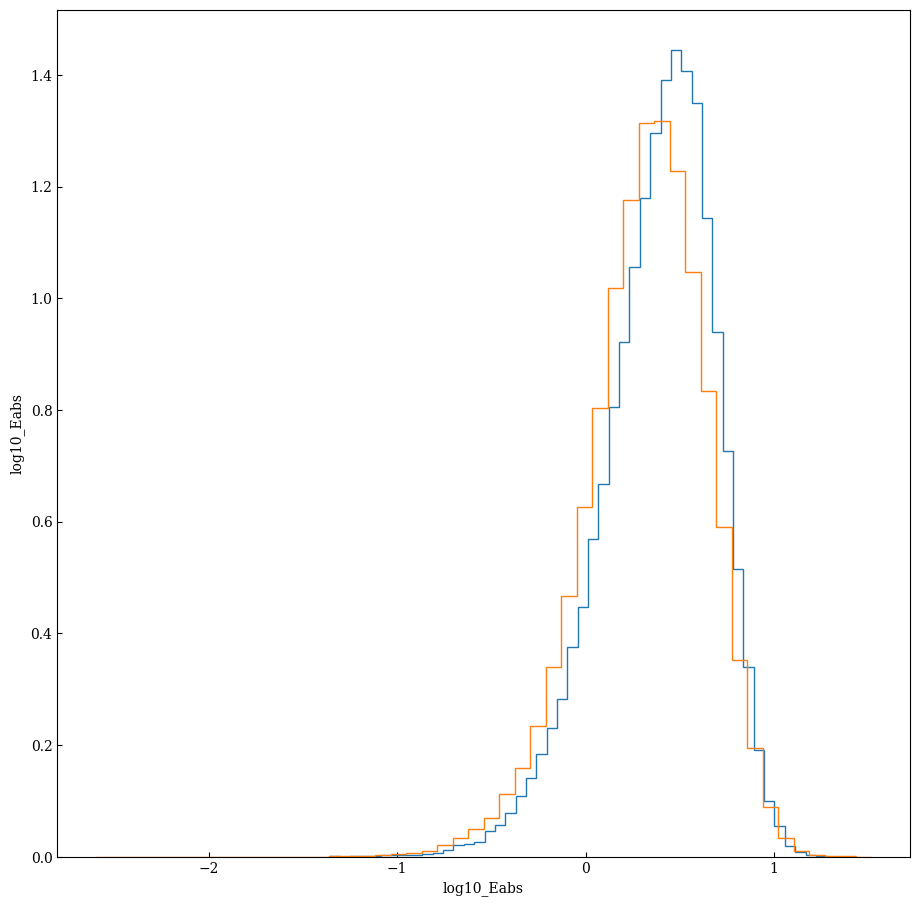

In [5]:
import astropy.units as u
import numpy as np
d.plot_ml_step(tau=30., temperature=50*u.K, nu=3e5*u.GHz, amax=1*u.um, nsamples=100000, plot_columns=np.array(["log10_Eabs"]))

In [13]:
d.save("amax.dst")

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("sim_results_pre-filter.csv", index_col=0)

In [33]:
import torch
features = ["log10_nu0", "log10_T", "log10_amax", "p", "log10_tau_cell_nu0"]
finish_probability = 1 - d.ml_step_filter_model(d.ml_step_filter_x_scaler.transform(torch.tensor(df.loc[:,features].values, dtype=torch.float32))).detach().numpy().flatten()

In [ ]:
df = df[finish_probability > 0.999]

In [39]:
good = np.logical_and(np.abs(df["log10_tau_cell_nu0"] - np.log10(10.)) < 0.1,
                      np.logical_and(np.abs(df["log10_T"] - np.log10(5000.)) < 0.1,
                                     np.logical_and(np.abs(df["log10_nu0"] - np.log10(3e5)) < 0.1,
                                                    np.logical_and(np.abs(df["log10_amax"] - -4.0) < 0.1,
                                                                   np.logical_and(np.abs(df["p"] - 3.5) < 0.1,
                                                                                  np.logical_not(df["in_grid"]))))))
